# <span style="color:green;">This Notebook takes the ultimate strength modulii equations as input and gives a 3D graph of modulus, density, and strain rate and an average regression equation</span>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

## <span style="color:blue;">Plotting the graph of the original models</span>

### Define ranges for independent variables (avoind zero to prevent log issues in power functions) (Su3 would lead to issues for any RHO less than 0.16)

In [3]:
rho = np.linspace(0.16, 5, 50)   # density range (0.15 → 2.5) with 50 points in btween
sr = np.linspace(0.001, 10.0, 50)    # strain rate range (0 → 1) with 50 points in btween

RHO, SR = np.meshgrid(rho, sr)

### Define regression equations for Su (ultimate strength) w.r.t. RHO (density) and sr (strain rate)

In [4]:
Su1 = 68 * RHO**2 * sr**0.06
Su2 = 40.2 * RHO**1.65 * sr**0.073
Su3 = (-5.8 + 37.1 * RHO) * sr**0.073
Su4 = 52.1 * RHO**2 * sr**0.070
Su5 = RHO**1.53 * (25.0 + 2.26 * sr)
Su6 = 51.5 * RHO**2 * sr**0.06
Su7 = 24.1 * RHO**1.07 * 1.35**0.83 * sr**0.11
Su8 = 5.09 * RHO**2.35 + 0.545 * sr**0.06


### Store models, labels, and colors

In [5]:
equations = [Su1, Su2, Su3, Su4, Su5, Su6, Su7, Su8]
labels = ["Model 1", "Model 2", "Model 3", "Model 4", "Model 5", "Model 6", "Model 7", "Model 8"]
colors = ["red", "green", "blue", "orange", "purple", "cyan", "magenta", "brown"]

### 3D Plot

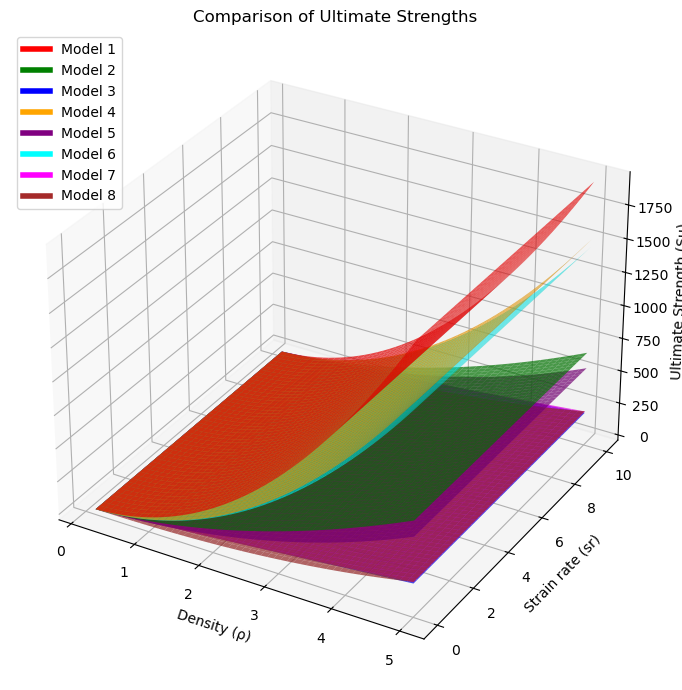

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for E, label, color in zip(equations, labels, colors):
    ax.plot_surface(RHO, SR, E, alpha=0.7, color=color)

# Axis labels and title
ax.set_xlabel("Density (ρ)")
ax.set_ylabel("Strain rate (sr)")
ax.set_zlabel("Ultimate Strength (Su)")
ax.set_title("Comparison of Ultimate Strengths")

# Legend (workaround for 3D plots)
custom_lines = [Line2D([0], [0], color=c, lw=4) for c in colors]
ax.legend(custom_lines, labels, loc='upper left')

plt.tight_layout()
# Save plot as image
plt.savefig("strength_modulus_plot.png", dpi=300)  # save as PNG, you can also use .jpg, .pdf, etc.

plt.show()

## <span style="color:blue;">Create an average regression function</span>

In [8]:
# Create a grid of all combinations
RHO_grid, sr_grid = np.meshgrid(rho, sr)
RHO_flat = RHO_grid.flatten()
sr_flat = sr_grid.flatten()

# Compute all original E values
def original_Su(RHO, sr):
    Su1 = 68 * RHO**2 * sr**0.06
    Su2 = 40.2 * RHO**1.65 * sr**0.073
    Su3 = (-5.8 + 37.1 * RHO) * sr**0.073
    Su4 = 52.1 * RHO**2 * sr**0.070
    Su5 = RHO**1.53 * (25.0 + 2.26 * sr)
    Su6 = 51.5 * RHO**2 * sr**0.06
    Su7 = 24.1 * RHO**1.07 * 1.35**0.83 * sr**0.11
    Su8 = 5.09 * RHO**2.35 + 0.545 * sr**0.06

    # Arithmetic mean
    return (Su1 + Su2 + Su3 + Su4 + Su5 + Su6 + Su7 + Su8) / 8

Su_mean = original_Su(RHO_flat, sr_flat)

# Define the analytical model to fit
def Su_model(X, A, a, b, C):
    RHO, sr = X
    return A * RHO**a * sr**b + C

# Fit the model
popt, _ = curve_fit(Su_model, (RHO_flat, sr_flat), Su_mean, p0=[5000, 2, 0, 0])

A_fit, a_fit, b_fit, C_fit = popt
print(f"Fitted model: Su_fit = {A_fit:.2f} * RHO^{a_fit:.2f} * sr^{b_fit:.2f} + {C_fit:.2f}")

Su_pred = Su_model((RHO_flat, sr_flat), *popt)

# Compute R²
ss_res = np.sum((Su_mean - Su_pred)**2)
ss_tot = np.sum((Su_mean - np.mean(Su_mean))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R² = {r2:.4f}")

Fitted model: Su_fit = 35.33 * RHO^1.87 * sr^0.07 + 3.40
R² = 0.9998


In [9]:
Su_fit = A_fit * RHO**a_fit * sr**b_fit + C_fit
equations.append(Su_fit)
labels.append("Fitted_model")
colors.append("black")

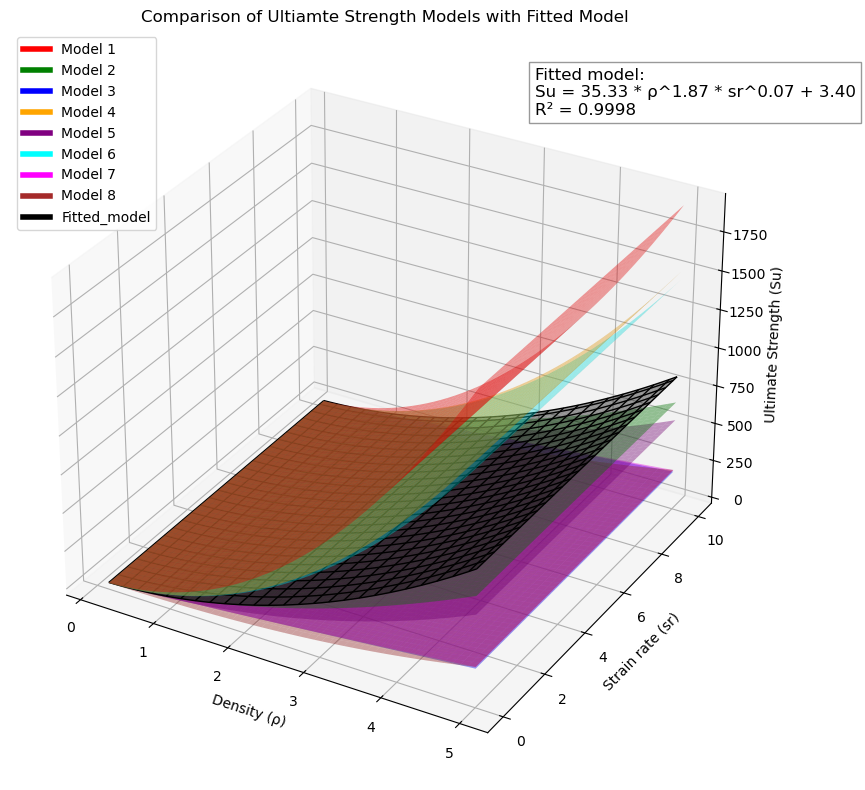

In [11]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot original models semi-transparent
for Su, label, color in zip(equations, labels, colors):
    ax.plot_surface(RHO, SR, Su, alpha=0.4, color=color)

# Plot fitted model as solid black wireframe
ax.plot_wireframe(RHO, SR, Su_fit, color="black", linewidth=1, rstride=2, cstride=2)

# Axis labels and title
ax.set_xlabel("Density (ρ)")
ax.set_ylabel("Strain rate (sr)")
ax.set_zlabel("Ultimate Strength (Su)")
ax.set_title("Comparison of Ultiamte Strength Models with Fitted Model")


# Coordinates to place the text (adjust as needed)
x_pos = 0 * np.max(RHO)
y_pos = 0 * np.max(SR)
z_pos = 0.7 * np.max([Su.max() for Su in equations])  # near the top

textstr = f"Fitted model:\nSu = {A_fit:.2f} * ρ^{a_fit:.2f} * sr^{b_fit:.2f} + {C_fit:.2f}\nR² = {r2:.4f}"
# Add R² and fitted parameters in a box on the right
ax.text2D(0.70, 0.95, textstr, transform=ax.transAxes,
          fontsize=12, verticalalignment='top',
          bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Legend (workaround for 3D plots)
custom_lines = [Line2D([0], [0], color=c, lw=4) for c in colors]
ax.legend(custom_lines, labels, loc='upper left')

plt.tight_layout()


# Save plot as image
plt.savefig("ultiamte_strength_plot-with_fitted_model.png", dpi=300)  # save as PNG, you can also use .jpg, .pdf, etc.

plt.show()

# Save equation and R² in a text file
with open("Ultimate_Strength_fitted_model.txt", "w", encoding="utf-8") as f:
    f.write(textstr)

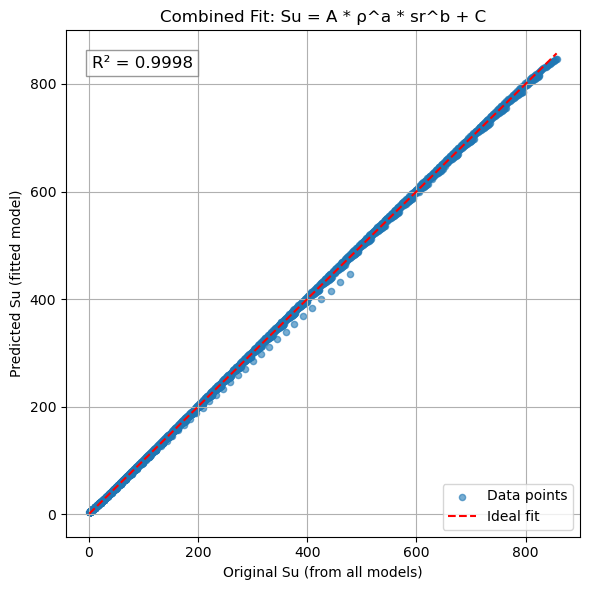

In [12]:
plt.figure(figsize=(6,6))

# Scatter plot of original vs predicted
plt.scatter(Su_mean, Su_pred, s=20, alpha=0.6, label="Data points")

# 1:1 reference line
plt.plot([Su_mean.min(), Su_mean.max()], [Su_mean.min(), Su_mean.max()], 'r--', label="Ideal fit")

# Labels and title
plt.xlabel("Original Su (from all models)")
plt.ylabel("Predicted Su (fitted model)")
plt.title("Combined Fit: Su = A * ρ^a * sr^b + C")
plt.grid(True)

# Add R² value as a textbox
plt.text(
    0.05, 0.95,                          # position in axes fraction
    f"R² = {r2:.4f}",                     # formatted R² value
    transform=plt.gca().transAxes,        # axes coordinates
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')  # background box
)

plt.legend()
plt.tight_layout()
# Save plot as image
plt.savefig("R2_regression_Su.png", dpi=300)  # save as PNG, you can also use .jpg, .pdf, etc.

plt.show()
